In [1]:
### importing libraries
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model saving
import joblib

# Statistics
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
## loading and inspecting the dataset
df = pd.read_csv("../data/raw/carbon_fiber_thermoplastic_experimental_662.csv")

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (662, 14)


In [4]:
df.head()

,specimen_id,source_group_pct,youngs_modulus_gpa,max_force_n,tensile_strength_mpa,elongation_at_max_force_pct,specimen_length_mm,specimen_mass_mg,fiber_concentration_pct,character,place,spot,composite_diameter_mm,cut_photo_available
0,Sample1.1,20,204.848452,1827.948608,4112.884369,1.682568,238.0,263.0,72.395437,L,A,B,0.96,yes
1,Sample1.2,20,203.617195,1652.758667,3718.707001,1.576634,238.0,263.0,72.395437,S,G,V,0.95,yes
2,Sample1.3,20,219.409201,1836.640747,4132.441681,1.652574,238.0,273.0,69.743590,S,G,V,0.96,yes
3,Sample1.4,20,205.736286,1806.208130,4063.968292,1.686891,238.0,258.0,73.798450,S,G,V,0.92,yes
4,Sample1.5,20,206.353258,1835.067871,4128.902710,1.732882,238.0,265.0,71.849057,S,G,V,0.95,yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   specimen_id                  662 non-null    str    
 1   source_group_pct             662 non-null    int64  
 2   youngs_modulus_gpa           662 non-null    float64
 3   max_force_n                  662 non-null    float64
 4   tensile_strength_mpa         662 non-null    float64
 5   elongation_at_max_force_pct  662 non-null    float64
 6   specimen_length_mm           662 non-null    float64
 7   specimen_mass_mg             662 non-null    float64
 8   fiber_concentration_pct      662 non-null    float64
 9   character                    660 non-null    str    
 10  place                        660 non-null    str    
 11  spot                         660 non-null    str    
 12  composite_diameter_mm        661 non-null    float64
 13  cut_photo_available          66

In [6]:
### checking missing values
df.isnull().sum()

specimen_id                    0
source_group_pct               0
youngs_modulus_gpa             0
max_force_n                    0
tensile_strength_mpa           0
elongation_at_max_force_pct    0
specimen_length_mm             0
specimen_mass_mg               0
fiber_concentration_pct        0
character                      2
place                          2
spot                           2
composite_diameter_mm          1
cut_photo_available            0
dtype: int64

In [7]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Check unique values in categorical columns
print("Character:")
print(df["character"].value_counts(dropna=False))

print("\nPlace:")
print(df["place"].value_counts(dropna=False))

print("\nSpot:")
print(df["spot"].value_counts(dropna=False))

print("\nPhoto availability:")
print(df["cut_photo_available"].value_counts(dropna=False))

Character:
character
S      486
L      142
X       31
NaN      2
G        1
Name: count, dtype: int64

Place:
place
G      388
A      264
I        8
NaN      2
Name: count, dtype: int64

Spot:
spot
V      407
T      140
B       99
M       12
NaN      2
U        2
Name: count, dtype: int64

Photo availability:
cut_photo_available
no     606
yes     56
Name: count, dtype: int64


In [9]:
# Numerical variables: minimum and maximum values
df.describe().T[["min", "max"]]

,min,max
source_group_pct,20.000000,40.000000
youngs_modulus_gpa,168.854370,231.380898
max_force_n,1171.020752,2255.293457
tensile_strength_mpa,2634.796692,5074.410278
elongation_at_max_force_pct,1.117246,3.379138
specimen_length_mm,220.000000,253.000000
specimen_mass_mg,222.000000,392.000000
fiber_concentration_pct,51.413333,82.051282
composite_diameter_mm,0.850000,1.200000


In [10]:
# Check whether any numerical values are zero or negative
numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    print(f"\n{col}")
    print("Zeros:", (df[col] == 0).sum())
    print("Negative values:", (df[col] < 0).sum())


source_group_pct
Zeros: 0
Negative values: 0

youngs_modulus_gpa
Zeros: 0
Negative values: 0

max_force_n
Zeros: 0
Negative values: 0

tensile_strength_mpa
Zeros: 0
Negative values: 0

elongation_at_max_force_pct
Zeros: 0
Negative values: 0

specimen_length_mm
Zeros: 0
Negative values: 0

specimen_mass_mg
Zeros: 0
Negative values: 0

fiber_concentration_pct
Zeros: 0
Negative values: 0

composite_diameter_mm
Zeros: 0
Negative values: 0


In [11]:
# Inspect the rows containing missing values
df[df.isnull().any(axis=1)]

,specimen_id,source_group_pct,youngs_modulus_gpa,max_force_n,tensile_strength_mpa,elongation_at_max_force_pct,specimen_length_mm,specimen_mass_mg,fiber_concentration_pct,character,place,spot,composite_diameter_mm,cut_photo_available
52,Sample2.24,20,212.026762,1533.021484,3449.298340,1.419050,237.0,247.0,76.761134,NaN,NaN,NaN,0.89,no
58,Sample3.1,20,213.865341,1818.997681,4092.744781,1.662384,240.0,252.0,76.190476,S,G,V,NaN,no
82,Sample3.25,20,210.073659,1787.736328,4022.406738,1.646531,240.0,247.0,77.732794,NaN,NaN,NaN,0.87,no


In [4]:
# Create a copy of the raw dataset
df_clean = df.copy()

# Remove rows with missing values
df_clean = df_clean.dropna().reset_index(drop=True)

print("Original dataset:", df.shape)
print("Clean dataset:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Original dataset: (662, 14)
Clean dataset: (659, 14)
Rows removed: 3


In [13]:
# Check that no missing values remain
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
specimen_id                    0
source_group_pct               0
youngs_modulus_gpa             0
max_force_n                    0
tensile_strength_mpa           0
elongation_at_max_force_pct    0
specimen_length_mm             0
specimen_mass_mg               0
fiber_concentration_pct        0
character                      0
place                          0
spot                           0
composite_diameter_mm          0
cut_photo_available            0
dtype: int64


In [14]:
# Check duplicates after cleaning
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [15]:
# Check the cleaned dataset
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 659 entries, 0 to 658
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   specimen_id                  659 non-null    str    
 1   source_group_pct             659 non-null    int64  
 2   youngs_modulus_gpa           659 non-null    float64
 3   max_force_n                  659 non-null    float64
 4   tensile_strength_mpa         659 non-null    float64
 5   elongation_at_max_force_pct  659 non-null    float64
 6   specimen_length_mm           659 non-null    float64
 7   specimen_mass_mg             659 non-null    float64
 8   fiber_concentration_pct      659 non-null    float64
 9   character                    659 non-null    str    
 10  place                        659 non-null    str    
 11  spot                         659 non-null    str    
 12  composite_diameter_mm        659 non-null    float64
 13  cut_photo_available          65

In [16]:
# Numerical columns to examine
numeric_cols = [
    "source_group_pct",
    "youngs_modulus_gpa",
    "max_force_n",
    "tensile_strength_mpa",
    "elongation_at_max_force_pct",
    "specimen_length_mm",
    "specimen_mass_mg",
    "fiber_concentration_pct",
    "composite_diameter_mm"
]

# Calculate IQR-based outlier counts
outlier_summary = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    
    outlier_summary.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,variable,Q1,Q3,lower_bound,upper_bound,outlier_count
0,source_group_pct,20.000000,40.000000,-10.000000,70.000000,0
1,youngs_modulus_gpa,206.968258,212.176647,199.155673,219.989232,23
2,max_force_n,1736.841553,1934.603210,1440.199066,2231.245697,7
3,tensile_strength_mpa,3907.893494,4352.857224,3240.447899,5020.302818,7
4,elongation_at_max_force_pct,1.610802,1.782605,1.353098,2.040309,6
5,specimen_length_mm,237.000000,241.000000,231.000000,247.000000,25
6,specimen_mass_mg,270.000000,316.000000,201.000000,385.000000,4
7,fiber_concentration_pct,60.964630,70.882353,46.088046,85.758937,0
8,composite_diameter_mm,0.960000,1.060000,0.810000,1.210000,0


In [17]:
Q1 = df_clean["tensile_strength_mpa"].quantile(0.25)
Q3 = df_clean["tensile_strength_mpa"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

potential_outliers = df_clean[
    (df_clean["tensile_strength_mpa"] < lower_bound) |
    (df_clean["tensile_strength_mpa"] > upper_bound)
]

print("Potential tensile-strength outliers:", len(potential_outliers))

potential_outliers[
    ["specimen_id", "source_group_pct",
     "fiber_concentration_pct", "composite_diameter_mm",
     "tensile_strength_mpa"]
]

Lower bound: 3240.447898864745
Upper bound: 5020.302818298341
Potential tensile-strength outliers: 7


,specimen_id,source_group_pct,fiber_concentration_pct,composite_diameter_mm,tensile_strength_mpa
207,Sample1.25,30,75.806452,0.88,3092.793640
450,Sample3.26,40,53.863636,1.15,5050.918213
461,Sample4.4,40,53.263158,1.14,5022.686646
479,Sample5.1,40,65.135135,1.04,2634.796692
535,Sample7.1,40,62.950820,1.07,5074.410278
570,Sample8.4,40,52.249322,1.15,5030.368286
631,Sample10.1,40,62.394822,1.05,5044.635132


## 4. Exploratory Data Analysis

Exploratory data analysis (EDA) is used to understand the distribution
of the experimental measurements and identify relationships between
material/process variables and tensile strength.

The target variable for this project is:

- `tensile_strength_mpa` — tensile strength of the composite specimen.

In [18]:
# Display descriptive statistics for tensile strength
df_clean["tensile_strength_mpa"].describe()

count     659.000000
mean     4136.680973
std       346.783191
min      2634.796692
25%      3907.893494
50%      4103.118622
75%      4352.857224
max      5074.410278
Name: tensile_strength_mpa, dtype: float64

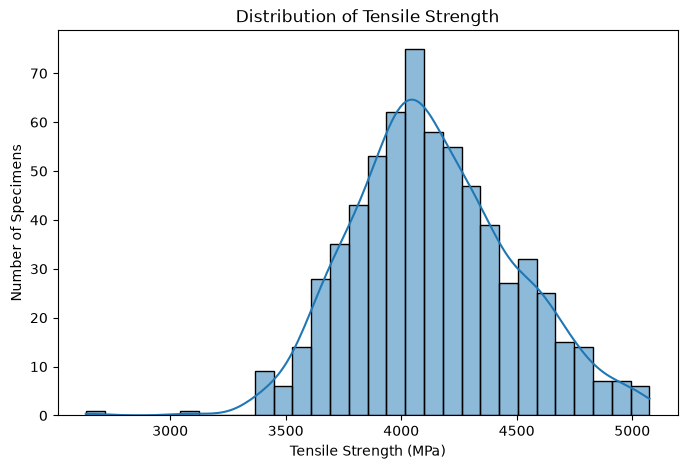

In [19]:
# Plot the distribution of tensile strength
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["tensile_strength_mpa"],
    bins=30,
    kde=True
)

plt.xlabel("Tensile Strength (MPa)")
plt.ylabel("Number of Specimens")
plt.title("Distribution of Tensile Strength")
plt.show()

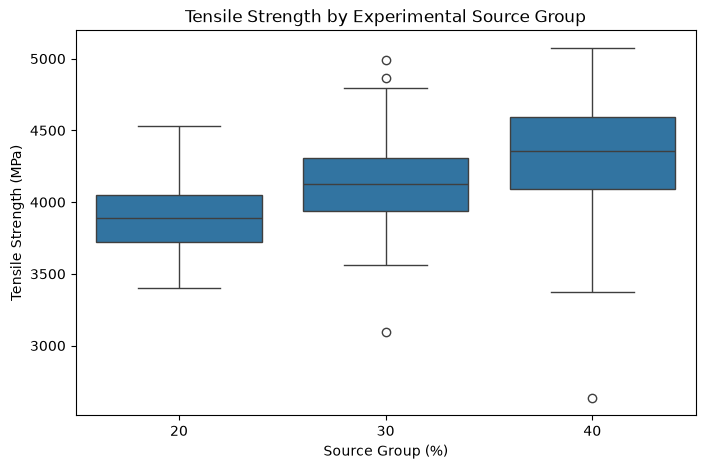

In [20]:
# Compare tensile strength across the three experimental source groups
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="source_group_pct",
    y="tensile_strength_mpa"
)

plt.xlabel("Source Group (%)")
plt.ylabel("Tensile Strength (MPa)")
plt.title("Tensile Strength by Experimental Source Group")
plt.show()

In [21]:
# Summarize the main material and mechanical variables
df_clean[
    [
        "source_group_pct",
        "fiber_concentration_pct",
        "tensile_strength_mpa"
    ]
].describe()

,source_group_pct,fiber_concentration_pct,tensile_strength_mpa
count,659.000000,659.000000,659.000000
mean,30.743551,65.932661,4136.680973
std,7.906719,7.594030,346.783191
min,20.000000,51.413333,2634.796692
25%,20.000000,60.964630,3907.893494
50%,30.000000,64.697987,4103.118622
75%,40.000000,70.882353,4352.857224
max,40.000000,82.051282,5074.410278


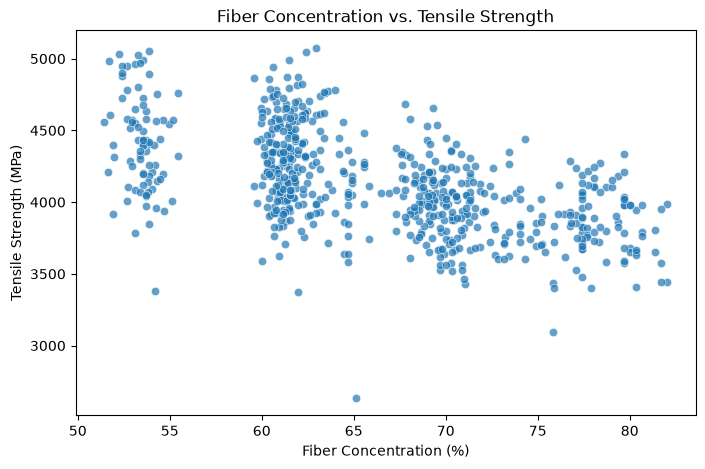

In [5]:
# Examine the relationship between fiber concentration and tensile strength
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="fiber_concentration_pct",
    y="tensile_strength_mpa",
    alpha=0.7
)

plt.xlabel("Fiber Concentration (%)")
plt.ylabel("Tensile Strength (MPa)")
plt.title("Fiber Concentration vs. Tensile Strength")
plt.show()

## 5. Correlation Analysis

Correlation analysis is used to examine the relationships between the
numerical variables in the experimental dataset.

This provides an initial understanding of which variables may be associated
with tensile strength. However, correlation does not imply causation, and
the machine-learning models will consider multiple variables simultaneously.

In [6]:
# Select the main numerical variables for correlation analysis
numerical_features = [
    "source_group_pct",
    "youngs_modulus_gpa",
    "max_force_n",
    "tensile_strength_mpa",
    "elongation_at_max_force_pct",
    "specimen_length_mm",
    "specimen_mass_mg",
    "fiber_concentration_pct",
    "composite_diameter_mm"
]

# Calculate the Pearson correlation matrix
correlation_matrix = df_clean[numerical_features].corr()

# Display the correlation matrix
correlation_matrix

,source_group_pct,youngs_modulus_gpa,max_force_n,tensile_strength_mpa,elongation_at_max_force_pct,specimen_length_mm,specimen_mass_mg,fiber_concentration_pct,composite_diameter_mm
source_group_pct,1.000000,-0.081737,0.527365,0.527365,0.483673,0.261228,0.763146,-0.788276,0.739211
youngs_modulus_gpa,-0.081737,1.000000,0.055141,0.055141,-0.174170,0.045113,0.085896,-0.084302,0.098262
max_force_n,0.527365,0.055141,1.000000,1.000000,0.913548,0.182279,0.553580,-0.568768,0.551639
tensile_strength_mpa,0.527365,0.055141,1.000000,1.000000,0.913548,0.182279,0.553580,-0.568768,0.551639
elongation_at_max_force_pct,0.483673,-0.174170,0.913548,0.913548,1.000000,0.141527,0.463459,-0.478245,0.465472
specimen_length_mm,0.261228,0.045113,0.182279,0.182279,0.141527,1.000000,0.501442,-0.378824,0.375849
specimen_mass_mg,0.763146,0.085896,0.553580,0.553580,0.463459,0.501442,1.000000,-0.982091,0.957895
fiber_concentration_pct,-0.788276,-0.084302,-0.568768,-0.568768,-0.478245,-0.378824,-0.982091,1.000000,-0.964617
composite_diameter_mm,0.739211,0.098262,0.551639,0.551639,0.465472,0.375849,0.957895,-0.964617,1.000000


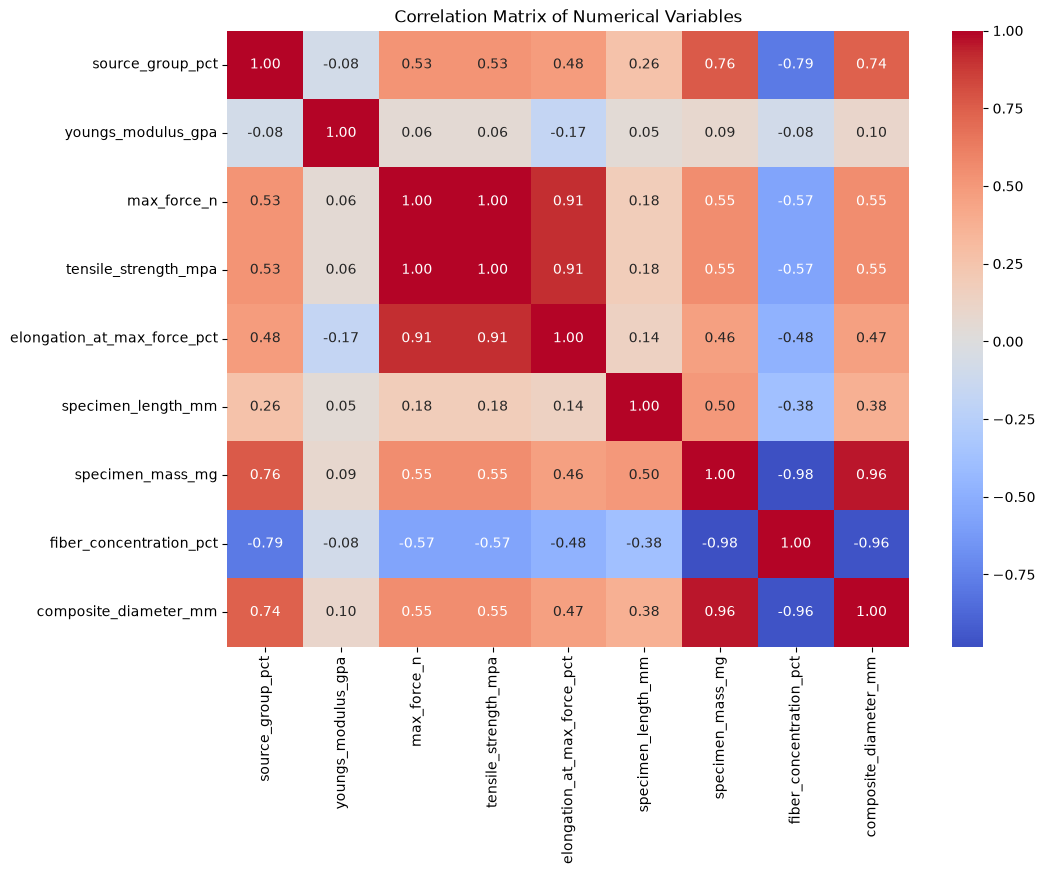

In [7]:
# Visualize correlations between the numerical variables
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Interpretation

The correlation matrix provides an initial view of how the measured
variables are related to tensile strength and to one another.

Strong correlations should be interpreted carefully because some
measurements may be derived from or collected during the same tensile
test. In particular, maximum force requires special consideration because
tensile strength is related to force and specimen cross-sectional area.

Therefore, correlation analysis will also help us identify potential
data-leakage risks before developing the machine-learning models.

## 6. Categorical Variable Inspection

The dataset contains categorical experimental descriptors that may
capture differences between specimens.

We first examine the number of observations in each category before
deciding whether these variables should be included in the predictive
models.

In [10]:
# Display the number of specimens in each category
categorical_features = [
    "character",
    "place",
    "spot"
]

for column in categorical_features:
    print(f"\n{column}")
    print(df_clean[column].value_counts())


character
character
S    485
L    142
X     31
G      1
Name: count, dtype: int64

place
place
G    387
A    264
I      8
Name: count, dtype: int64

spot
spot
V    406
T    140
B     99
M     12
U      2
Name: count, dtype: int64


## 6. Feature Selection

The objective of the machine-learning model is to predict tensile strength
from material and specimen characteristics that can be known independently
of the tensile-strength result.

Test-derived mechanical properties and variables directly involved in the
calculation of tensile strength are excluded to reduce data leakage.

The selected input variables are:

- Source group
- Fiber concentration
- Specimen length
- Specimen mass
- Composite diameter
- Character
- Place
- Spot

The target variable is tensile strength.

In [50]:
features = [
    "source_group_pct",
    "fiber_concentration_pct",
    "specimen_length_mm",
    "specimen_mass_mg",
    "composite_diameter_mm"
]

target = "tensile_strength_mpa"

X = df_clean[features]
y = df_clean[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['source_group_pct', 'fiber_concentration_pct', 'specimen_length_mm', 'specimen_mass_mg', 'composite_diameter_mm']

Target:
tensile_strength_mpa

X shape: (659, 5)
y shape: (659,)


In [51]:
# Display the first five rows of the selected features
X.head()

,source_group_pct,fiber_concentration_pct,specimen_length_mm,specimen_mass_mg,composite_diameter_mm
0,20,72.395437,238.0,263.0,0.96
1,20,72.395437,238.0,263.0,0.95
2,20,69.743590,238.0,273.0,0.96
3,20,73.798450,238.0,258.0,0.92
4,20,71.849057,238.0,265.0,0.95


In [52]:
# Display the first five target values
y.head()

0    4112.884369
1    3718.707001
2    4132.441681
3    4063.968292
4    4128.902710
Name: tensile_strength_mpa, dtype: float64

## 7. Train-Test Split

The dataset is divided into training and testing subsets.

The training set will be used to develop the machine-learning models,
while the test set will be kept separate for final performance evaluation.

A fixed random state is used so that the experiment is reproducible.

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (527, 5)
Testing features: (132, 5)
Training target: (527,)
Testing target: (132,)


## 8 Data Preprocessing

The selected predictors are all numerical variables, so categorical
encoding is not required.

The machine-learning models used in this study are tree-based regression
models, which do not require feature scaling. Therefore, the five
numerical predictors are used directly without standardization or
normalization.

This keeps the preprocessing pipeline simple while preserving the
original physical units of the variables.

In [54]:
numerical_features = [
    "source_group_pct",
    "fiber_concentration_pct",
    "specimen_length_mm",
    "specimen_mass_mg",
    "composite_diameter_mm"
]

print("Preprocessing complete.")
print("Numerical features used:")
print(numerical_features)

Preprocessing complete.
Numerical features used:
['source_group_pct', 'fiber_concentration_pct', 'specimen_length_mm', 'specimen_mass_mg', 'composite_diameter_mm']


## 9. Random Forest Regression

A Random Forest regression model is trained to predict tensile strength
from the selected material, processing, and specimen characteristics.

Random Forest combines multiple decision trees to capture nonlinear
relationships between the input variables and tensile strength.

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE:  {rf_mae:.2f} MPa")
print(f"Random Forest RMSE: {rf_rmse:.2f} MPa")
print(f"Random Forest R²:   {rf_r2:.3f}")

Random Forest MAE:  218.70 MPa
Random Forest RMSE: 275.97 MPa
Random Forest R²:   0.163


## 10. Gradient Boosting Regression

A Gradient Boosting regression model is trained as a second
tree-based approach.

Gradient Boosting builds an ensemble of decision trees sequentially,
with each new tree attempting to improve the errors made by the
previous trees.

The model is evaluated using MAE, RMSE, and R² on the held-out
test set.

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting MAE:  {gb_mae:.2f} MPa")
print(f"Gradient Boosting RMSE: {gb_rmse:.2f} MPa")
print(f"Gradient Boosting R²:   {gb_r2:.3f}")

Gradient Boosting MAE:  223.48 MPa
Gradient Boosting RMSE: 284.50 MPa
Gradient Boosting R²:   0.110


## 11. XGBoost Regression

XGBoost is evaluated as a third tree-based regression approach.

The model builds an ensemble of decision trees sequentially, with each
new tree improving the predictions of the previous trees.

XGBoost is evaluated using the same held-out test set and the same
performance metrics as the Random Forest and Gradient Boosting models.

In [57]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE:  {xgb_mae:.2f} MPa")
print(f"XGBoost RMSE: {xgb_rmse:.2f} MPa")
print(f"XGBoost R²:   {xgb_r2:.3f}")

XGBoost MAE:  218.11 MPa
XGBoost RMSE: 276.13 MPa
XGBoost R²:   0.162


## 12. Model Comparison

The three regression models are compared using the same held-out test
set and the same evaluation metrics: Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and coefficient of determination (R²).

Lower MAE and RMSE indicate smaller prediction errors, while a higher
R² indicates that the model explains more of the variation in tensile
strength.

In [58]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE (MPa)": [
        rf_mae,
        gb_mae,
        xgb_mae
    ],
    "RMSE (MPa)": [
        rf_rmse,
        gb_rmse,
        xgb_rmse
    ],
    "R²": [
        rf_r2,
        gb_r2,
        xgb_r2
    ]
})

results

,Model,MAE (MPa),RMSE (MPa),R²
0,Random Forest,218.700827,275.965892,0.162606
1,Gradient Boosting,223.476397,284.502309,0.109998
2,XGBoost,218.111586,276.129349,0.161613


## 13. Five-Fold Cross-Validation

Five-fold cross-validation is used to evaluate the stability of the
three machine-learning models across multiple validation subsets.

The training data are divided into five folds. Each fold is used once
as validation data while the remaining four folds are used for training.

This provides a more robust estimate of model performance than relying
on a single train-test split.

In [59]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

models = {
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results.append({
        "Model": name,
        "CV MAE (MPa)": -scores["test_MAE"].mean(),
        "CV MAE Std": scores["test_MAE"].std(),
        "CV RMSE (MPa)": -scores["test_RMSE"].mean(),
        "CV RMSE Std": scores["test_RMSE"].std(),
        "CV R²": scores["test_R2"].mean(),
        "CV R² Std": scores["test_R2"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,CV MAE (MPa),CV MAE Std,CV RMSE (MPa),CV RMSE Std,CV R²,CV R² Std
0,Random Forest,258.034461,12.960006,325.949354,28.421155,0.156199,0.049140
1,Gradient Boosting,262.217868,11.027011,334.053533,25.743345,0.113261,0.028545
2,XGBoost,253.079541,16.601808,321.633141,34.141060,0.178048,0.086813


## 14. Final Model Selection

The three machine-learning models were evaluated using both a held-out
test set and five-fold cross-validation.

XGBoost showed the strongest average cross-validation performance,
achieving the lowest mean absolute error (253.08 MPa), lowest root
mean squared error (321.63 MPa), and highest R² (0.178) among the
three evaluated models.

Therefore, XGBoost is selected as the final model for the remainder
of the analysis.

The relatively modest R² indicates that substantial variation in
tensile strength remains unexplained by the selected pre-test
features. The model should therefore be interpreted as a predictive
screening tool rather than a replacement for experimental tensile
testing.

In [60]:
final_model = xgb_model

print("Final model selected: XGBoost")

Final model selected: XGBoost


## 15. Actual vs. Predicted Tensile Strength

The predicted tensile strengths from the final XGBoost model are compared
with the measured tensile strengths from the held-out test set.

A scatter plot is used to assess how closely the predictions follow the
ideal relationship between predicted and measured values.

The dashed diagonal line represents perfect prediction, where predicted
tensile strength equals the experimentally measured value.

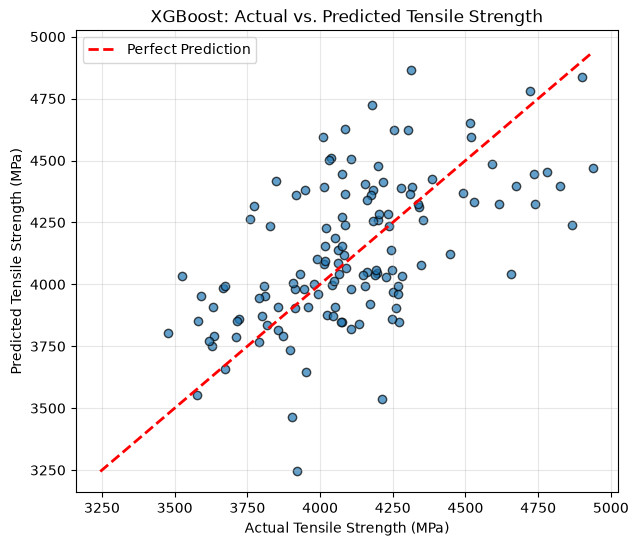

In [61]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.7,
    edgecolor="k"
)

min_value = min(y_test.min(), y_pred_xgb.min())
max_value = max(y_test.max(), y_pred_xgb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Tensile Strength (MPa)")
plt.ylabel("Predicted Tensile Strength (MPa)")
plt.title("XGBoost: Actual vs. Predicted Tensile Strength")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 16. Residual Analysis

Residuals are calculated as the difference between the experimentally
measured tensile strength and the tensile strength predicted by the
final XGBoost model.

Residual analysis is used to determine whether prediction errors are
randomly distributed or whether systematic patterns remain in the model.

A well-behaved residual plot should show points distributed around zero
without a clear trend or systematic structure.

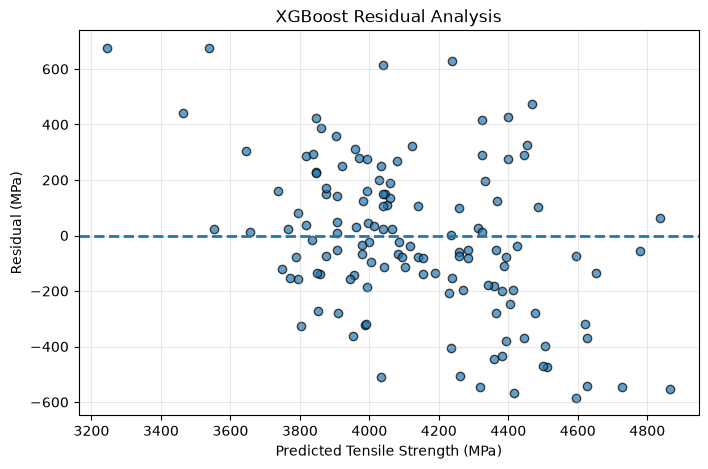

In [62]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_xgb,
    residuals,
    alpha=0.7,
    edgecolor="k"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Tensile Strength (MPa)")
plt.ylabel("Residual (MPa)")
plt.title("XGBoost Residual Analysis")
plt.grid(alpha=0.3)

plt.show()

## 17. Feature Importance

Feature importance is examined to understand the relative contribution of
the selected input variables to the predictions made by the final XGBoost
model.

The analysis considers the five pre-test variables used by the model:
source group, fiber concentration, specimen length, specimen mass, and
composite diameter.

Feature importance indicates how strongly a variable was used by the model
for prediction. It should not be interpreted as evidence of a causal
relationship between the variable and tensile strength.

In [63]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,fiber_concentration_pct,0.351531
0,source_group_pct,0.241742
3,specimen_mass_mg,0.183366
2,specimen_length_mm,0.120853
4,composite_diameter_mm,0.102509


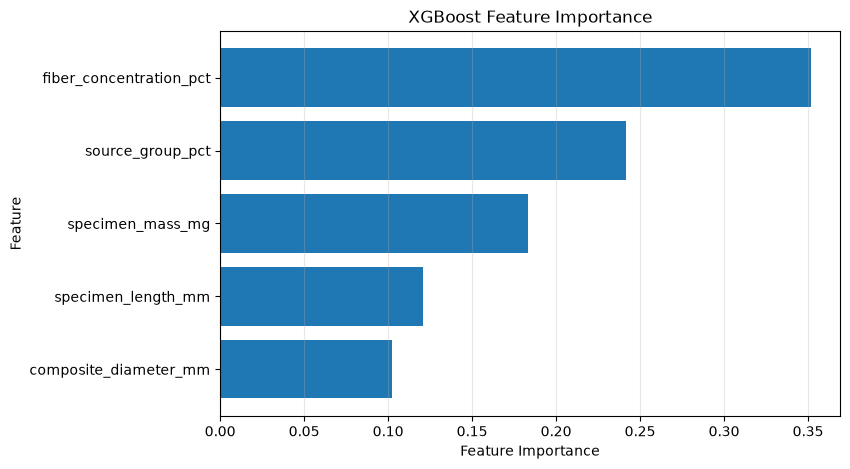

In [64]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

## 15. Actual vs. Predicted Tensile Strength

The actual-versus-predicted relationship is examined for all three
machine-learning models.

This provides a visual comparison of how closely each model reproduces
the experimentally measured tensile strengths on the unseen test set.

In [30]:
# Generate predictions from all three trained models
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_gb = gb_pipeline.predict(X_test)
y_pred_xgb = xgb_pipeline.predict(X_test)

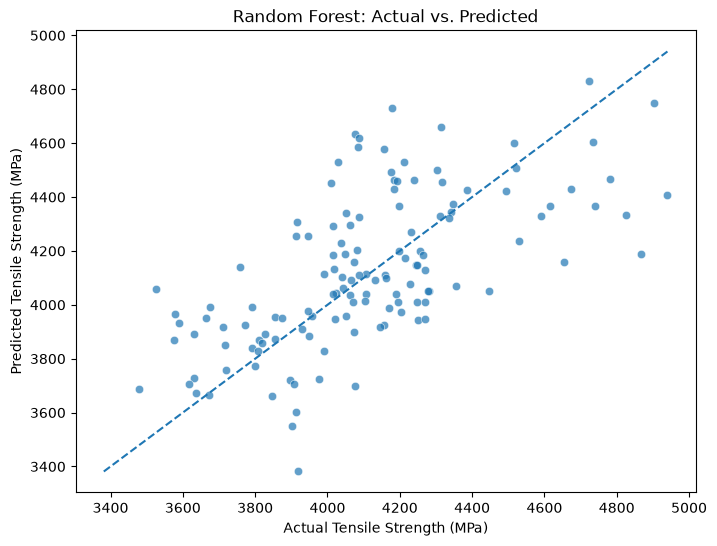

In [31]:
# Random Forest: actual vs. predicted tensile strength
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.7
)

# Add the 1:1 reference line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tensile Strength (MPa)")
plt.ylabel("Predicted Tensile Strength (MPa)")
plt.title("Random Forest: Actual vs. Predicted")

plt.show()

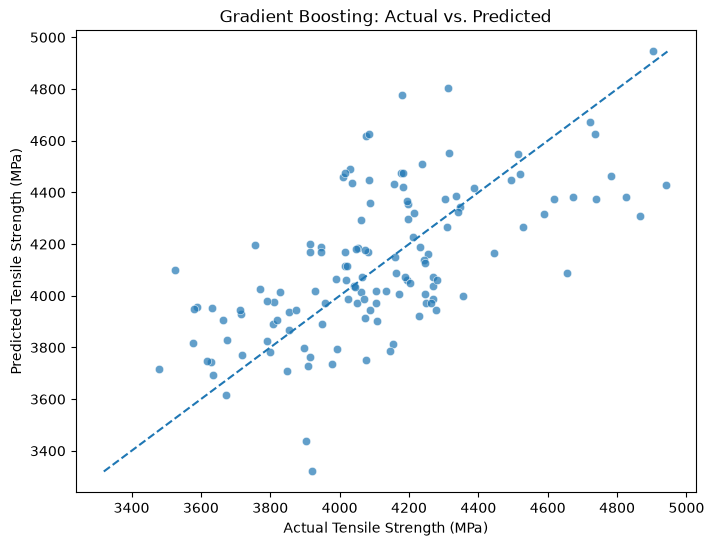

In [32]:
# Gradient Boosting: actual vs. predicted tensile strength
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_gb,
    alpha=0.7
)

# Add the 1:1 reference line
min_value = min(y_test.min(), y_pred_gb.min())
max_value = max(y_test.max(), y_pred_gb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tensile Strength (MPa)")
plt.ylabel("Predicted Tensile Strength (MPa)")
plt.title("Gradient Boosting: Actual vs. Predicted")

plt.show()

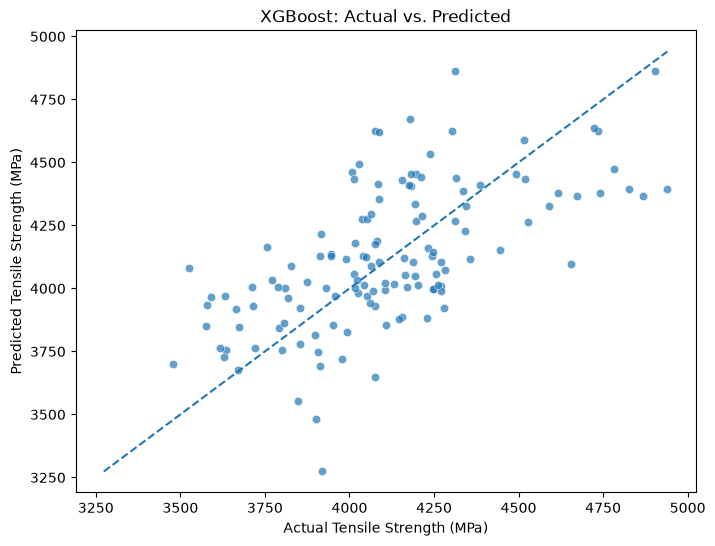

In [33]:
# XGBoost: actual vs. predicted tensile strength
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_xgb,
    alpha=0.7
)

# Add the 1:1 reference line
min_value = min(y_test.min(), y_pred_xgb.min())
max_value = max(y_test.max(), y_pred_xgb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tensile Strength (MPa)")
plt.ylabel("Predicted Tensile Strength (MPa)")
plt.title("XGBoost: Actual vs. Predicted")

plt.show()

## 16. Residual Analysis

Residuals represent the difference between the experimentally measured
tensile strength and the model-predicted tensile strength.

Residual analysis is performed for all three models to determine whether
there are systematic differences in their prediction errors.

In [34]:
# Calculate residuals for each model
residuals_rf = y_test - y_pred_rf
residuals_gb = y_test - y_pred_gb
residuals_xgb = y_test - y_pred_xgb

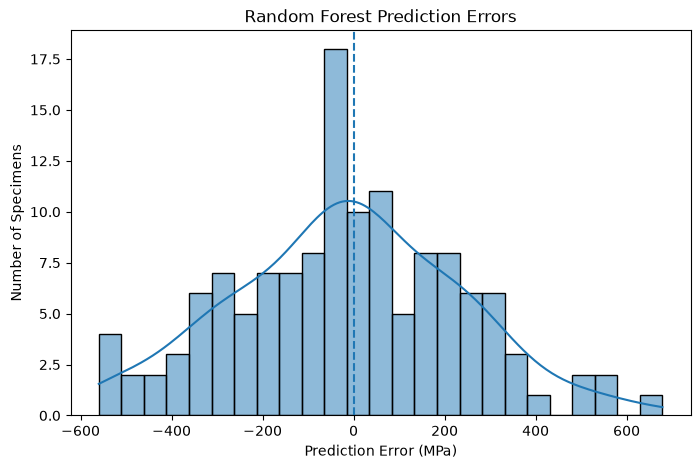

In [35]:
# Plot Random Forest residuals
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals_rf,
    bins=25,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error (MPa)")
plt.ylabel("Number of Specimens")
plt.title("Random Forest Prediction Errors")

plt.show()

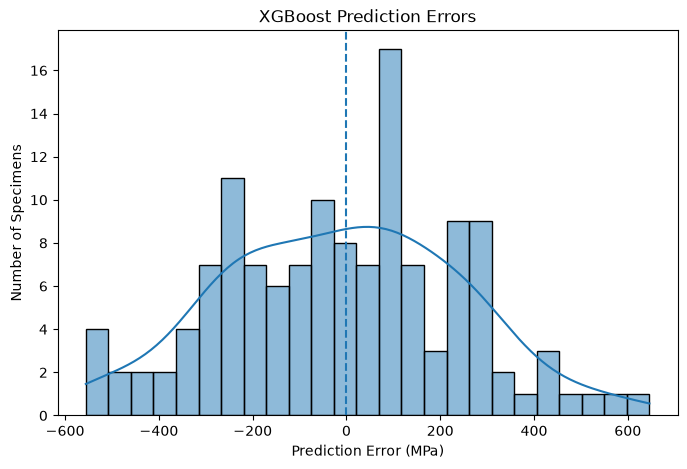

In [36]:
# Plot XGBoost residuals
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals_xgb,
    bins=25,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error (MPa)")
plt.ylabel("Number of Specimens")
plt.title("XGBoost Prediction Errors")

plt.show()

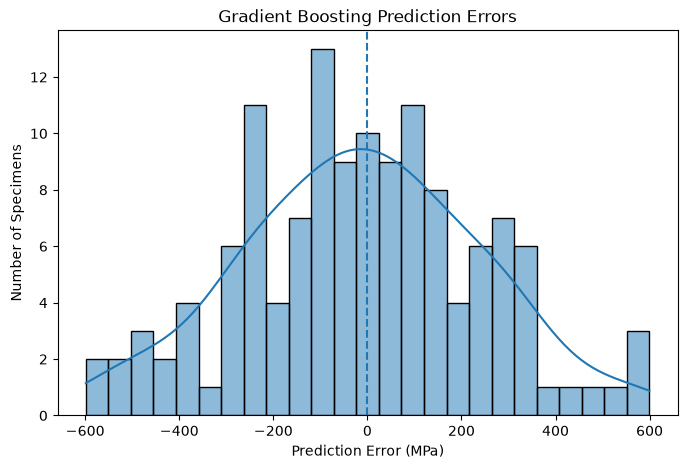

In [38]:
# Plot Gradient Boosting residuals
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals_gb,
    bins=25,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error (MPa)")
plt.ylabel("Number of Specimens")
plt.title("Gradient Boosting Prediction Errors")

plt.show()

## 17. Five-Fold Cross-Validation

Five-fold cross-validation is used to assess the stability of the
machine-learning models.

The training dataset is divided into five subsets (folds). Each fold is
used once as validation data while the remaining four folds are used for
training.

The process is repeated until all five folds have been used for validation.

This provides a more robust estimate of model performance than relying
on a single train-test split.

In [39]:
from sklearn.model_selection import cross_validate, KFold

# Create a reproducible five-fold cross-validation strategy
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define the evaluation metrics
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

print("Five-fold cross-validation setup complete.")

Five-fold cross-validation setup complete.


In [40]:
# Evaluate the Random Forest using five-fold cross-validation
rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# Evaluate Gradient Boosting
gb_cv = cross_validate(
    gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# Evaluate XGBoost
xgb_cv = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Cross-validation completed for all three models.")

Cross-validation completed for all three models.


## 19. Cross-Validation Results

The mean and standard deviation of each evaluation metric are calculated
across the five validation folds.

The mean provides an estimate of typical model performance, while the
standard deviation indicates how much performance varies between folds.

In [41]:
# Create a summary of cross-validation performance
cv_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "CV MAE (MPa)": [
        -rf_cv["test_MAE"].mean(),
        -gb_cv["test_MAE"].mean(),
        -xgb_cv["test_MAE"].mean()
    ],
    "CV MAE Std": [
        rf_cv["test_MAE"].std(),
        gb_cv["test_MAE"].std(),
        xgb_cv["test_MAE"].std()
    ],
    "CV RMSE (MPa)": [
        -rf_cv["test_RMSE"].mean(),
        -gb_cv["test_RMSE"].mean(),
        -xgb_cv["test_RMSE"].mean()
    ],
    "CV R²": [
        rf_cv["test_R2"].mean(),
        gb_cv["test_R2"].mean(),
        xgb_cv["test_R2"].mean()
    ],
    "CV R² Std": [
        rf_cv["test_R2"].std(),
        gb_cv["test_R2"].std(),
        xgb_cv["test_R2"].std()
    ]
})

cv_results.round(3)

,Model,CV MAE (MPa),CV MAE Std,CV RMSE (MPa),CV R²,CV R² Std
0,Random Forest,211.094,12.040,269.811,0.420,0.025
1,Gradient Boosting,214.815,13.441,275.621,0.393,0.064
2,XGBoost,208.981,12.438,265.131,0.440,0.047


## 18. Cross-Validation Results

Five-fold cross-validation was used to evaluate the stability of the
three machine-learning models across multiple validation folds.

The cross-validation results showed that XGBoost achieved the lowest
average MAE and RMSE and the highest average R² among the three models.

Random Forest showed slightly lower variability in R² across folds,
while Gradient Boosting showed comparatively greater variation.

The results indicate that model performance depends somewhat on the
particular training and validation split, highlighting the importance
of evaluating models using both a held-out test set and cross-validation.

In [42]:
# Select XGBoost based on its cross-validation performance
final_model = xgb_pipeline

# Retrain on the complete training dataset
final_model.fit(X_train, y_train)

# Evaluate on the untouched test set
y_pred_final = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print(f"Final Model: XGBoost")
print(f"Test MAE:  {final_mae:.2f} MPa")
print(f"Test RMSE: {final_rmse:.2f} MPa")
print(f"Test R²:   {final_r2:.3f}")

Final Model: XGBoost
Test MAE:  207.07 MPa
Test RMSE: 252.50 MPa
Test R²:   0.299


## 19. Save the Final Model

The trained XGBoost pipeline is saved for later use in the
deployment application. The complete pipeline is saved so that
the same preprocessing and feature encoding used during training
are automatically applied when new experimental inputs are provided.

In [43]:
import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/xgboost_tensile_strength_pipeline.joblib"

joblib.dump(final_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../models/xgboost_tensile_strength_pipeline.joblib


In [44]:
loaded_model = joblib.load(model_path)

test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Test predictions:")
print(test_prediction)

Test predictions:
[4435.2354 4326.838  3757.1177 4534.2173 3841.6262]


## 20. Baseline Model Comparison

A simple baseline model is used to provide a reference point for
evaluating the machine-learning model.

The baseline predicts the mean tensile strength of the training
data for every specimen. The XGBoost model is then compared with
this baseline using the same held-out test set.

Comparing the machine-learning model with a simple baseline helps
determine whether the model is learning useful relationships between
the input material/specimen characteristics and tensile strength.

In [45]:
# Predict the mean tensile strength of the training set
# for every specimen in the test set.

baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

print(f"Baseline prediction: {y_train.mean():.2f} MPa")

Baseline prediction: 4143.69 MPa


In [46]:
# Calculate baseline performance

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline Model Performance")
print(f"MAE:  {baseline_mae:.2f} MPa")
print(f"RMSE: {baseline_rmse:.2f} MPa")
print(f"R²:   {baseline_r2:.3f}")

Baseline Model Performance
MAE:  233.10 MPa
RMSE: 303.60 MPa
R²:   -0.013


In [47]:
# Compare the baseline with the final XGBoost model

comparison = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "XGBoost"
    ],
    "MAE (MPa)": [
        baseline_mae,
        final_mae
    ],
    "RMSE (MPa)": [
        baseline_rmse,
        final_rmse
    ],
    "R²": [
        baseline_r2,
        final_r2
    ]
})

comparison.round(3)

,Model,MAE (MPa),RMSE (MPa),R²
0,Mean Baseline,233.095,303.597,-0.013
1,XGBoost,207.072,252.504,0.299


In [48]:
# Load the saved pipeline
loaded_model = joblib.load(model_path)

# Generate predictions for five test specimens
test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Test predictions:")
print(test_prediction)

Test predictions:
[4435.2354 4326.838  3757.1177 4534.2173 3841.6262]


In [49]:
comparison_test = pd.DataFrame({
    "Actual Tensile Strength (MPa)": y_test.iloc[:5].values,
    "Predicted Tensile Strength (MPa)": test_prediction
})

comparison_test

,Actual Tensile Strength (MPa),Predicted Tensile Strength (MPa)
0,4520.236542,4435.235352
1,4346.022766,4326.837891
2,3635.301819,3757.117676
3,4238.227936,4534.217285
4,3790.221130,3841.626221
